# Stage 1: Purchase Propensity Model

Binary classifier predicting **whether a customer will purchase in the 180-day holdout window**.

- **Target:** `purchased_in_holdout = (actual_holdout_transactions > 0)` — ~12.3% positive
- **Model:** XGBoost with `scale_pos_weight` for class imbalance + isotonic calibration
- **Primary metric:** PR-AUC (baseline = 0.123)

**Outputs:**
- `models/purchase_propensity_model.pkl`
- `data/processed/stage1_scored.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, 
    roc_auc_score,
    precision_recall_curve
)
import xgboost as xgb

# Settings
sns.set_style('darkgrid')

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv("../data/raw/clv_data.csv")

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")

Loaded 52,507 customers
Positive class (purchased in holdout): 6,451 (12.3%)
Negative class (no holdout purchase):  46,056 (87.7%)


## 2. Exploratory Data Analysis

Before modeling, we examine distributions, class balance, and feature relationships to inform feature engineering and model design choices.

In [4]:
df.head()

,user_id,frequency,recency,T,monetary_value,total_orders,total_spend,avg_order_value,days_since_last_order,actual_holdout_transactions,...,country,total_sessions,total_events,days_since_last_visit,avg_events_per_session,distinct_event_types,cart_events,product_view_events,purchase_events,purchased_in_holdout
0,34756,1,993,1064,411.750000,2,465.490002,232.745001,71,0,...,China,7,82,70,11.714286,4,25,25,7,0
1,9513,2,743,1062,94.719997,3,297.019993,99.006664,319,0,...,China,6,49,319,8.166667,5,14,14,6,0
2,74483,2,436,685,150.335000,3,321.920000,107.306667,249,1,...,South Korea,7,71,249,10.142857,5,21,21,7,1
3,69957,1,138,1701,196.759998,2,239.569998,119.784999,1563,0,...,France,7,82,1559,11.714286,4,25,25,7,0
4,67994,2,362,1576,156.990001,3,435.670000,145.223333,1214,0,...,China,8,80,1214,10.000000,4,24,24,8,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,52507.0,49948.269907,28893.416003,1.00,24831.500000,50046.000000,74923.000000,99999.000000
frequency,52507.0,0.422896,0.726733,0.00,0.000000,0.000000,1.000000,3.000000
recency,52507.0,165.316301,346.131637,0.00,0.000000,0.000000,132.000000,2164.000000
T,52507.0,723.394290,532.090185,8.00,275.000000,615.000000,1092.000000,2276.000000
monetary_value,52507.0,86.550571,91.819948,0.02,30.000000,58.000000,109.949997,1264.599995
total_orders,52507.0,1.422896,0.726733,1.00,1.000000,1.000000,2.000000,4.000000
total_spend,52507.0,122.773543,127.423234,0.02,39.500000,79.989998,164.369999,1469.869999
avg_order_value,52507.0,86.382369,85.545582,0.02,34.211251,61.099999,109.575417,1264.599995
days_since_last_order,52507.0,558.077990,477.968901,1.00,173.000000,419.000000,829.000000,2263.000000
actual_holdout_transactions,52507.0,0.137525,0.388232,0.00,0.000000,0.000000,0.000000,3.000000


### 2.1 Target and Feature Distributions

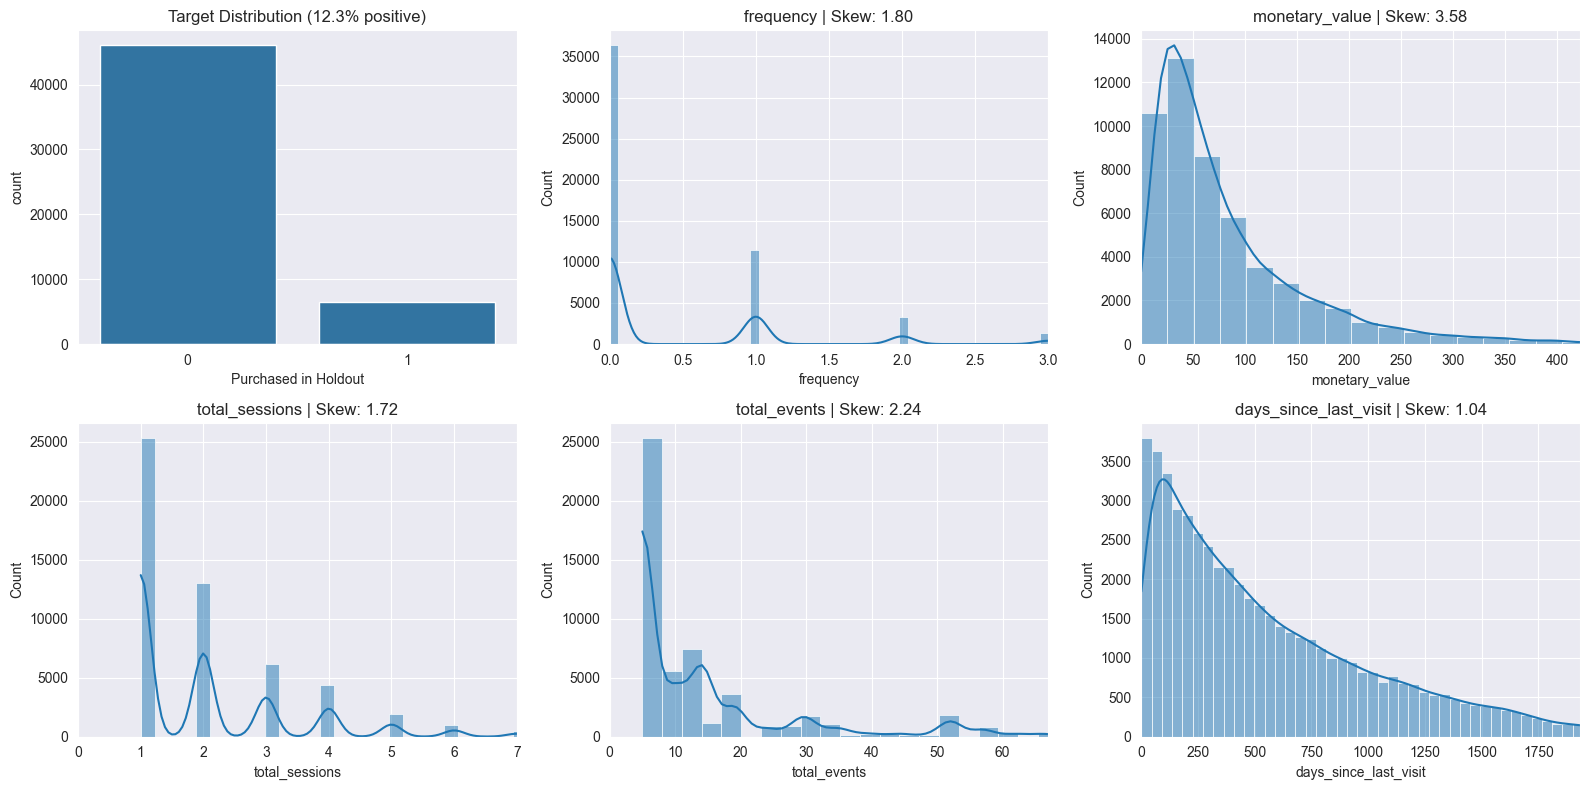

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Row 1: Target + purchase history
positive_rate = df['purchased_in_holdout'].mean()
sns.countplot(x='purchased_in_holdout', data=df, ax=axes[0, 0])
axes[0, 0].set_title(f"Target Distribution ({positive_rate:.1%} positive)")
axes[0, 0].set_xlabel("Purchased in Holdout")

for i, feat in enumerate(['frequency', 'monetary_value']):
    sns.histplot(df[feat], bins=50, kde=True, ax=axes[0, i+1])
    axes[0, i+1].set_title(f"{feat} | Skew: {df[feat].skew():.2f}")
    axes[0, i+1].set_xlim(0, df[feat].quantile(0.99))

# Row 2: Engagement features
for i, feat in enumerate(['total_sessions', 'total_events', 'days_since_last_visit']):
    sns.histplot(df[feat], bins=50, kde=True, ax=axes[1, i])
    axes[1, i].set_title(f"{feat} | Skew: {df[feat].skew():.2f}")
    axes[1, i].set_xlim(0, df[feat].quantile(0.99))

plt.tight_layout()
plt.show()

**Observations:**

- **Class imbalance:** Only 12.3% of customers purchase in the holdout window. This rules out accuracy as a metric (a "predict everyone as no-purchase" model gets 87.7%) and motivates the use of PR-AUC and `scale_pos_weight` in training.
- **Low repeat rates:** ~69% of customers are one-time buyers (`frequency = 0`). The model must discriminate among customers with very sparse purchase histories.
- **Right-skewed engagement:** `total_sessions`, `total_events`, and `monetary_value` are heavily right-skewed with long tails — a small segment of customers drives disproportionate activity. This suggests that *rate-based* features (e.g., sessions per day, purchase frequency per unit of tenure) may be more informative than raw counts, since raw counts conflate activity level with account age.
- **Recency signal:** `days_since_last_visit` spans a wide range (1 – 2,263 days), suggesting that recency relative to tenure — not raw recency alone — is the meaningful signal.

### 2.2 Feature Correlations

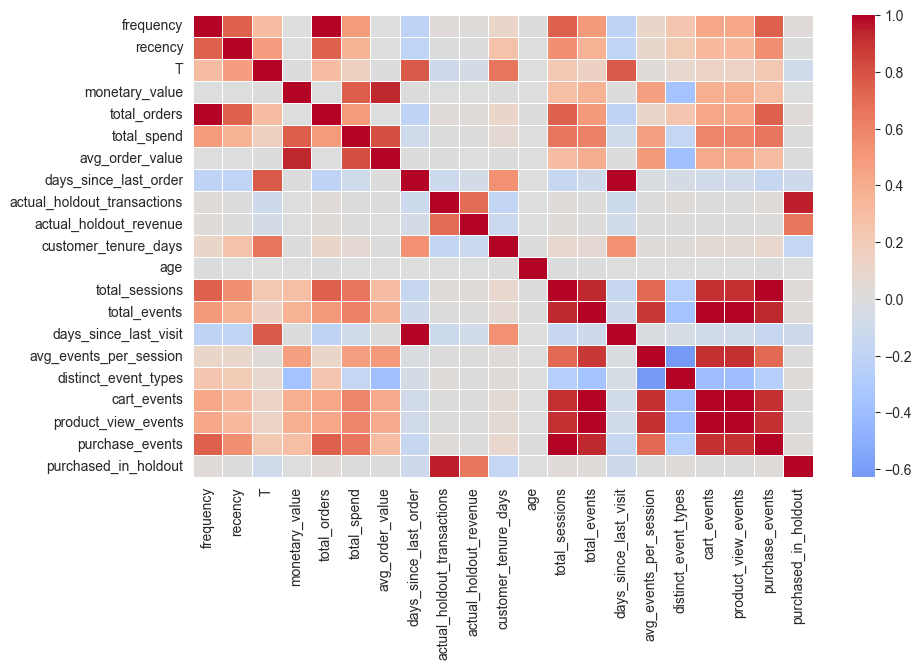

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.drop('user_id')
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', linewidth=0.5, center=0)
plt.show()

**Observations:**

- `cart_events` and `product_view_events` are perfectly correlated (identical values in the data — see `describe()` output above). One is redundant. We retain both since XGBoost handles redundancy gracefully, but this is worth noting for interpretability.
- Purchase history features (`frequency`, `total_orders`, `total_spend`) form a correlated cluster, as do engagement features (`total_sessions`, `total_events`). Tree-based models are robust to multicollinearity, so we do not drop correlated features — but these clusters confirm that the feature space has fewer effective dimensions than the raw feature count suggests.
- `days_since_last_order` and `days_since_last_visit` are near-identical, indicating that most customer "visits" coincide with purchases rather than independent browsing.

### 2.3 Key Takeaways for Modeling

1. **Class imbalance (12.3% positive)** requires `scale_pos_weight` during training and PR-AUC as the primary metric. Accuracy would be misleading.
2. **Right-skewed features + wide tenure range** motivate normalizing raw counts by tenure to create rate-based features (e.g., `purchase_rate = frequency / T`, `sessions_per_day`).
3. **Recency matters more than activity volume.** The spread of `days_since_last_visit` and `days_since_last_order` suggests that *when* a customer last engaged is more informative than *how much* they engaged in total.
4. **Many features carry redundant signal.** Correlated clusters and identical columns (`cart_events` ≡ `product_view_events`) mean the effective feature space is smaller than it appears. We expect a small number of features to drive most of the model's discrimination.

## 3. Feature Engineering

Based on the EDA findings — particularly the wide tenure range and right-skewed raw counts — we create rate-normalized features that measure *intensity* of behavior rather than *total volume*. We also compute ratio features that capture how recently a customer was active relative to their overall lifespan.

In [9]:
# Derived features 
# what fraction of lifetime included repeat activity
df['recency_ratio'] = df['recency'] / df['T']

# Purchase intensity
df["purchase_rate"] = df["frequency"] / df["T"]

# Recency relative to tenure
df["recency_tenure_ratio"] = df["days_since_last_order"] / df["customer_tenure_days"]

# Engagement intensity
df["events_per_day"] = df["total_events"] / df["customer_tenure_days"]
df["sessions_per_day"] = df["total_sessions"] / df["customer_tenure_days"]

# Shopping intent
df["cart_rate"] = df["cart_events"] / df["total_sessions"]
df["view_rate"] = df["product_view_events"] / df["total_sessions"]

NUMERIC_FEATURES = [
    # Purchase history (BG/NBD inputs)
    'frequency', 'recency', 'T', 'monetary_value',
    # Transaction context
    'total_orders', 'avg_order_value', 'days_since_last_order',
    # Demographics
    'customer_tenure_days', 'age',
    # Engagement
    'total_sessions', 'total_events', 'days_since_last_visit',
    'avg_events_per_session', 'cart_events', 'product_view_events',
    # Derived
    'recency_ratio', 'purchase_rate', 'recency_tenure_ratio', 
    'events_per_day', 'sessions_per_day',
    'cart_rate', 'view_rate'
]

CATEGORICAL_FEATURES = ['gender', 'traffic_source', 'country']

# Encode categorical features
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

FEATURE_COLS = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df['purchased_in_holdout']

print(f"Features: {len(FEATURE_COLS)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features: 25
Target distribution: {0: 46056, 1: 6451}


## 4. Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test):,} ({y_test.mean():.1%} positive)")

Train: 42,005 (12.3% positive)
Test:  10,502 (12.3% positive)


## 5. Train XGBoost Classifier

In [11]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0,
)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
clf

scale_pos_weight = 7.14


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

## 6. Probability Calibration

`scale_pos_weight` distorts raw probabilities. Isotonic regression calibrates them to match the true positive rate.
- `scale_pos_weight` helps the model pay attention to rare positives by increasing the loss contribution of positive examples. This effectively makes the algorithm behave as if positives are more common than they actually are. As a result, the model optimizes a **weighted loss rather than the true data distribution**, which improves classification performance on imbalanced data but can produce **poorly calibrated (typically inflated) probability estimates**.
- If we only care about **ranking customers** (e.g., top 10% marketing targets), calibration isn't critical. However, if probabilities are used for revenue forecasting, expected conversion rates, or decision thresholds, calibration becomes important.

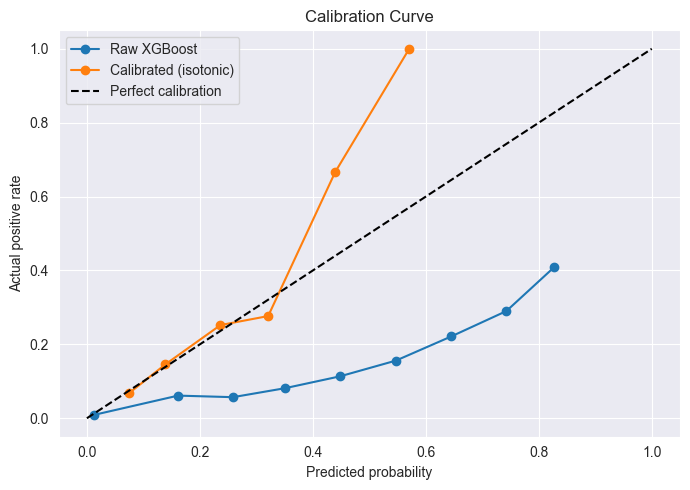

In [12]:
cal_clf = CalibratedClassifierCV(clf, method='isotonic', cv=5)  # isotonic regression learns monotonic function but doesn't assume a specific shape.
cal_clf.fit(X_train, y_train)

# Calibration curve on test set
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]
y_prob_raw = clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [('Raw XGBoost', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Evaluation

In [13]:
y_prob = cal_clf.predict_proba(X_test)[:, 1]
baseline = y_test.mean()

pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Purchase Propensity Model ===")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"ROC-AUC:  {roc_auc:.4f}")

# Cross-validation stability check
from sklearn.model_selection import cross_val_score
scores = cross_val_score(cal_clf, X, y, cv=5, scoring="average_precision")
print(f"\n5-fold CV PR-AUC: {scores.mean():.4f} \u00b1 {scores.std():.4f}")
print(f"  \u2192 CV mean is lower than test-set PR-AUC, suggesting moderate variance across folds.")
print(f"  \u2192 The model's discrimination is real but modest — consistent with the limited repeat-purchase signal in this dataset.")

=== Purchase Propensity Model ===
PR-AUC:   0.2262  (baseline: 0.1228, lift: 1.8x)
ROC-AUC:  0.6745

5-fold CV PR-AUC: 0.1841 ± 0.0313
  → CV mean is lower than test-set PR-AUC, suggesting moderate variance across folds.
  → The model's discrimination is real but modest — consistent with the limited repeat-purchase signal in this dataset.


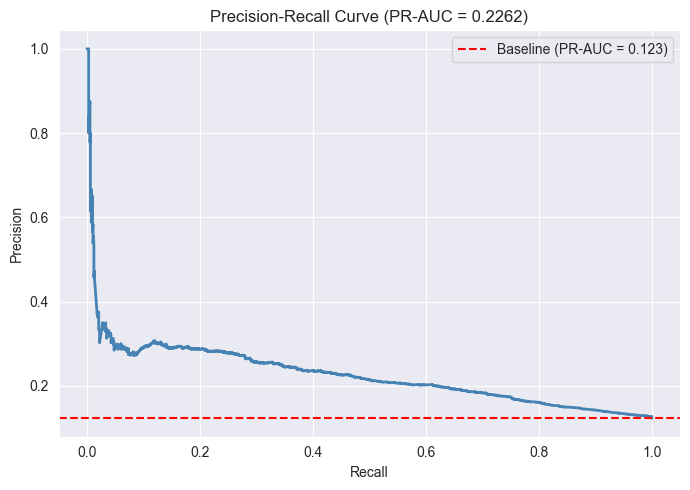

In [14]:
# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (PR-AUC = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers  = ('y_true', 'count'),
    actual_rate  = ('y_true', 'mean'),
    avg_prob     = ('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis ===")
print(decile_stats.to_string())
print(f"\nTop decile purchase rate: {decile_stats.iloc[-1]['actual_rate']:.1%}")
print(f"Bottom decile purchase rate: {decile_stats.iloc[0]['actual_rate']:.1%}")
print(f"Lift (top vs bottom): {decile_stats.iloc[-1]['actual_rate'] / max(decile_stats.iloc[0]['actual_rate'], 0.001):.1f}x")

=== Decile Analysis ===
        n_customers  actual_rate  avg_prob
decile                                    
1              1085       0.0479    0.0439
2              1170       0.0615    0.0733
3               896       0.0759    0.0799
4              1052       0.0751    0.0854
5              1048       0.0821    0.0944
6              1050       0.1057    0.1087
7              1050       0.1505    0.1283
8              1054       0.1603    0.1527
9              1046       0.1893    0.1940
10             1051       0.2826    0.2645

Top decile purchase rate: 28.3%
Bottom decile purchase rate: 4.8%
Lift (top vs bottom): 5.9x


## 8. Feature Importance

- **Feature importance:** Which features did the model use the most? (i.e., how much each feature helped split the tress during training.); Computed during training.
- **Permutation importance:** How much does model performance drop if we destroy the information in a feature? (i.e., how much the model actually relies on that feature during prediction.); Computed after training.

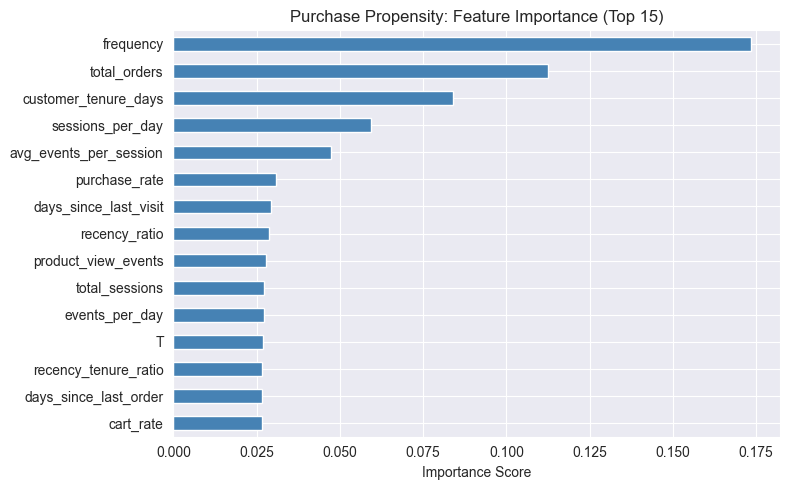

In [16]:
importance = pd.Series(clf.feature_importances_, index=FEATURE_COLS)
top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Purchase Propensity: Feature Importance (Top 15)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [42]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "weight": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("weight", ascending=False).reset_index(drop=True)

perm_df.style.background_gradient(subset=["weight"], cmap="RdYlGn")

,feature,weight,std
0,customer_tenure_days,0.048035,0.002055
1,sessions_per_day,0.029500,0.003147
2,days_since_last_order,0.014531,0.005464
3,days_since_last_visit,0.011821,0.002667
4,frequency,0.010923,0.001498
5,monetary_value,0.007846,0.002490
6,T,0.004110,0.001830
7,events_per_day,0.004057,0.002088
8,recency,0.003266,0.002179
9,purchase_rate,0.002342,0.000819


**Interpretation:**

Permutation importance reveals that the model's discrimination is driven by a small number of features:

- **`customer_tenure_days`** is the single strongest predictor — longer-tenured customers have had more time to return, and their non-return is a stronger signal of churn.
- **`sessions_per_day`** (a derived feature from EDA) ranks second, validating the decision to normalize engagement by tenure. Raw `total_sessions` ranks much lower, confirming that intensity matters more than volume.
- **Recency features** (`days_since_last_visit`, `days_since_last_order`) and **purchase history** (`frequency`, `monetary_value`) form the next tier.
- **Demographic features contribute negligibly or negatively** — `age`, `country_enc`, and `gender_enc` have near-zero or negative importance, meaning the model would perform equally well without them.
- **Several new features underperformed:** `cart_rate` and `view_rate` add no value (importance ≈ 0), likely because `cart_events` and `product_view_events` are identical and already captured by other features. A pruned model using ~8–10 features would likely achieve comparable performance.

The EDA prediction that "a small number of features will drive most discrimination" (Section 2.3, point 4) is confirmed.

## 9. Score All Customers and Save

In [44]:
# Score entire dataset
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

print(f"p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")

p_purchase distribution:
count    52507.0000
mean         0.1235
std          0.0671
min          0.0000
25%          0.0804
50%          0.1013
75%          0.1520
max          0.6987
Name: p_purchase, dtype: float64

Mean p_purchase: 0.1235 (base rate: 0.1229)


In [45]:
# Save model and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to data/processed/stage1_scored.csv
  Shape: 52,507 x 36


In [46]:
# Summary
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity")
print("=" * 50)
print(f"Customers scored:  {len(df):,}")
print(f"PR-AUC:            {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift over baseline)")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 03_clv_regression.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity
Customers scored:  52,507
PR-AUC:            0.2262 (1.8x lift over baseline)
ROC-AUC:           0.6745
Mean p_purchase:   0.1235

Next: 03_clv_regression.ipynb (Stage 2)
